<a href="https://colab.research.google.com/github/componavt/dictorpus-space/blob/main/notebooks/ludic_verb_stems_distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 📊 Ludic Verb Stem Distribution Visualization

This notebook cell clones the `dictorpus-space` repo, loads the `ludic_verb_stems_distribution.csv` file, and visualizes the distribution of Ludic verb stems.  
- 🔍 Reads lemma-level statistics for one-stem and two-stem verb types from VepKar dictionary data.  
- 📈 Draws a horizontal bar chart with **two Y-axes**: left for one-stem (plus “other”), right for two-stem verbs.  
- ↔️ One-stem bars grow rightward from 0; two-stem bars grow leftward from the right edge, making both systems visually comparable.  
- 🎨 Uses grayscale + hatching for print-friendly black-and-white publication, with counts inside bars and percentages outside.  
- 💾 Saves the resulting figure in both PNG and TIFF formats for inclusion in the article.  

✅ Repository ready

Saved: ludic_verb_stems_double_axis.png, ludic_verb_stems_double_axis.tif


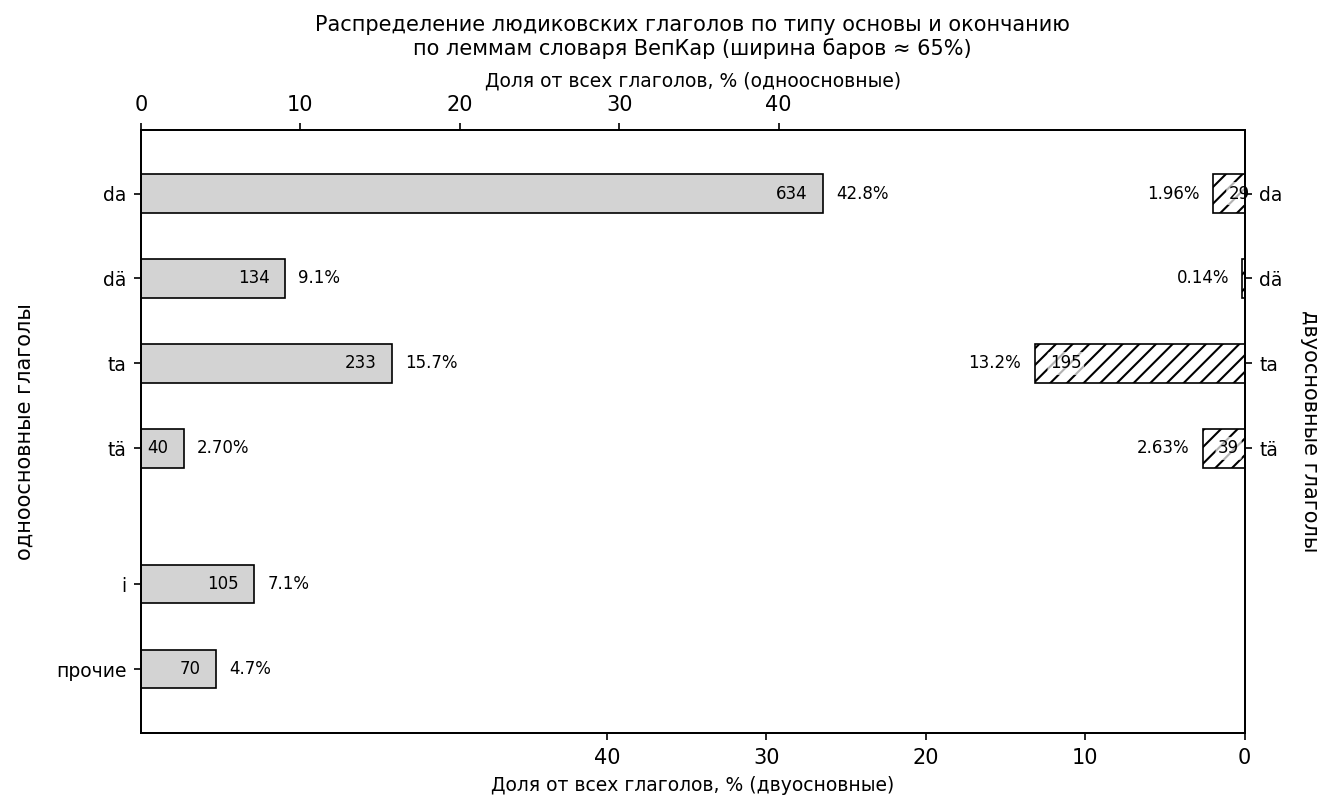

In [20]:
# 📥 [0] Clone repository and load data

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.family"] = "DejaVu Sans"

# === Display parameters ===
ANNOT_BG_ALPHA   = 0.7
X_WIDTH_PERCENT  = 65

# === Step 1: Clone repository ===
github_user = "componavt"
repo        = "dictorpus-space"
repo_path   = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}
print("✅ Repository ready\n")

# === Step 2: Load CSV ===
csv_path = "src/notebooks/ludic_verb_stems_distribution.csv"
df_raw = pd.read_csv(csv_path)
df_raw = df_raw[df_raw["type"] != "total"].copy()

def get_val(ending, type_):
    r = df_raw[(df_raw["ending"] == ending) & (df_raw["type"] == type_)]
    return (int(r.iloc[0]["count"]), float(r.iloc[0]["percent"])) if not r.empty else (0, 0.0)

# Left side: one-stem + other
left_labels = ["da", "dä", "ta", "tä", "i", "прочие"]
left_cnts, left_pcts = [], []
for lbl in ["da", "dä", "ta", "tä", "i"]:
    c, p = get_val(lbl, "one_stem")
    left_cnts.append(c); left_pcts.append(p)
c, p = get_val("other", "other")
left_cnts.append(c); left_pcts.append(p)
left_cnts = np.array(left_cnts)
left_pcts = np.array(left_pcts)

# Right side: two-stem
right_labels = ["da", "dä", "ta", "tä"]
right_cnts, right_pcts = [], []
for lbl in right_labels:
    c, p = get_val(lbl, "two_stem")
    right_cnts.append(c); right_pcts.append(p)
right_cnts = np.array(right_cnts)
right_pcts = np.array(right_pcts)

# Y positions
y_left  = np.array([0.0, 1.0, 2.0, 3.0, 4.6, 5.6])
y_right = np.array([0.0, 1.0, 2.0, 3.0])


def draw_chart():
    lv = left_pcts
    rv = right_pcts

    base_max = max(45.0, lv.max() * 1.05, rv.max() * 1.05)
    scale = X_WIDTH_PERCENT / 100.0
    x_max = base_max / scale
    bar_h = 0.45

    fig, ax = plt.subplots(figsize=(9, 5.5))

    # ── Left bars ────────────────────────────────────────────────────────
    ax.barh(y_left, lv, height=bar_h, color="lightgray",
            edgecolor="black", linewidth=0.8, align="center")

    for y, val, cnt, pct in zip(y_left, lv, left_cnts, left_pcts):
        ax.text(val - 0.014 * x_max, y, str(cnt),
                va="center", ha="right", fontsize=8)
        pct_str = f"{pct:.1f}%" if pct > 3 else f"{pct:.2f}%"
        ax.text(val + 0.012 * x_max, y, pct_str,
                va="center", ha="left", fontsize=8)

    # ── Right bars ───────────────────────────────────────────────────────
    for y, val, cnt, pct, label in zip(
        y_right, rv, right_cnts, right_pcts, right_labels
    ):
        left_edge = x_max - val
        ax.barh(y, val, left=left_edge, height=bar_h,
                color="white", edgecolor="black", hatch="///",
                linewidth=0.8, align="center")

        if label in ["da", "ta", "tä"]:
            txt = ax.text(left_edge + 0.014 * x_max, y, str(cnt),
                          va="center", ha="left", fontsize=8)
            txt.set_bbox(dict(facecolor="white", edgecolor="none",
                              boxstyle="round,pad=0.15", alpha=ANNOT_BG_ALPHA))

        pct_str = f"{pct:.1f}%" if pct > 3 else f"{pct:.2f}%"
        ax.text(left_edge - 0.012 * x_max, y, pct_str,
                va="center", ha="right", fontsize=8)

    # ── Axes limits & Y axis ─────────────────────────────────────────────
    ax.set_xlim(0, x_max)
    ax.set_ylim(y_left.max() + 0.75, y_left.min() - 0.75)

    ax.set_yticks(y_left)
    ax.set_yticklabels(left_labels, fontsize=9)
    ax.set_ylabel("одноосновные глаголы", fontsize=10, labelpad=10)

    # ── 🔧 КЛЮЧЕВОЕ ИСПРАВЛЕНИЕ: Сначала создаём ВСЕ оси ─────────────────

    # Нижняя ось X (двуосновные)
    ax_bot = ax.twiny()
    ax_bot.set_xlim(0, x_max)

    # Правая ось Y (двуосновные labels)
    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks(y_right)
    ax2.set_yticklabels(right_labels, fontsize=9)
    ax2.set_ylabel("двуосновные глаголы", fontsize=10, rotation=-90, labelpad=18)

    # ── 🔧 ТЕПЕРЬ настраиваем тики ПОСЛЕ создания всех осей ──────────────

    # ВЕРХНЯЯ ось X (одноосновные): 0→40 слева направо
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    top_ticks = [0, 10, 20, 30, 40]
    ax.set_xticks(top_ticks)
    ax.set_xticklabels([str(t) for t in top_ticks])
    ax.set_xlabel("Доля от всех глаголов, % (одноосновные)", fontsize=9)

    # 🔧 Явно скрываем НИЖНИЕ тики у ax
    ax.tick_params(axis='x', bottom=False, labelbottom=False)

    # НИЖНЯЯ ось X (двуосновные): 40←0 справа налево
    ax_bot.xaxis.set_ticks_position("bottom")
    ax_bot.xaxis.set_label_position("bottom")
    bottom_tick_values = [0, 10, 20, 30, 40]
    bottom_tick_positions = [x_max - v for v in bottom_tick_values]
    ax_bot.set_xticks(bottom_tick_positions)
    ax_bot.set_xticklabels([str(v) for v in bottom_tick_values])
    ax_bot.set_xlabel("Доля от всех глаголов, % (двуосновные)", fontsize=9)

    # 🔧 Явно скрываем ВЕРХНИЕ тики у ax_bot
    ax_bot.tick_params(axis='x', top=False, labeltop=False)

    ax.set_title(
        "Распределение людиковских глаголов по типу основы и окончанию\n"
        f"по леммам словаря ВепКар (ширина баров ≈ {X_WIDTH_PERCENT}%)",
        fontsize=10, pad=8
    )

    plt.tight_layout()

    out_png = "ludic_verb_stems_double_axis.png"
    out_tif = "ludic_verb_stems_double_axis.tif"
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    try:
        fig.savefig(out_tif, dpi=300, bbox_inches="tight")
        print(f"Saved: {out_png}, {out_tif}")
    except Exception as e:
        print(f"PNG saved ({out_png}); TIFF failed: {e}")

    plt.show()


draw_chart()